# Prueba U de Mann-Whitney (parte 2): TEST A/B

Somos Científicos de Datos en una tienda online. El equipo de marketing ha desarrollado una nueva versión de la página del producto (versión B) con un diseño más moderno. 

**Quieren saber si esta nueva versión incrementa el gasto por usuario en comparación con la versión actual (versión A)**

## 1. Desarrollo de la prueba de hipótesis

Este es un ejemplo clásico de una prueba A/B. Veamos cómo diseñar el experimento y cómo aplicar e interpretar la prueba de hipótesis.

### 1.1. Paso 1: definir el problema del negocio

> **¿Es mayor el gasto de los usuarios que visitaron el sitio B vs. los que visitaron el sitio A?**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> **¿El diseño del sitio web B incrementa la mediana del gasto con respecto al sitio A desde el punto de vista estadístico?**

### 1.3. Paso 3: definir $H_0$ y $H_1$

- $H_0$: ambos diseños de sitio tienen la misma mediana de gastos: $\theta_A = \theta_B$
- $H_1$: el diseño del sitio B tiene una mediana de gasto **mayor** que la el del sitio A: $\theta_A < \theta_B$

Observaciones:

- Como estamos asumiendo en $H_1$ que $\theta_A < \theta_B$ usaremos una prueba unilateral

### 1.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$.

### 1.5. Paso 5: definir la potencia de la prueba ($1-\beta$) y el tamaño de las muestras ($n_1$, $n_2$)

Al igual que en la lección anterior, en el caso de esta prueba tampoco tendremos un modelo matemático que nos permita estimar dichos tamaños, **así que nuevamente usaremos aproximaciones basadas en la distribución t**.

#### 1.5.1. El tamaño del efecto

En este caso podemos seguir usando la correlación biserial de rango (RBC) **pero ahora la ecuación cambia**:

$$RBC = 1 - \frac{2U}{n_A n_B}$$

Y los rangos más usuales son los mismos que vimos en la lección anterior:

- $\text{RBC} \geq 0.1$: efecto "pequeño"
- $\text{RBC} \geq 0.3$: efecto "mediano"
- $\text{RBC} \geq 0.5$: efecto "grande"

Asumiremos entonces un tamaño mediano ($RBC = 0.3$) y tras la prueba calcularemos el tamaño del efecto obtenido.

De nuevo, en un momento tendremos que hacer la equivalencia del $RBC$ con el tamaño del efecto de Cohen (d), para lo cual usaremos la misma ecuación vista en la lección anterior:

$$d = \frac{2\text{RBC}}{\sqrt{1-\text{RBC}^2}}$$

#### 1.5.2. La potencia de la prueba

Asumiremos una potencia de 0.9 y tras la prueba haremos el cálculo post-hoc.

#### 1.5.3. Aproximación: estimación de los tamaños de muestra

En este caso ocurre algo similar que para la prueba de Wilcoxon. Para una misma potencia de la prueba, la relación entre la cantidad de datos de cada muestra en U Mann Whitney comparada con el t-test de muestras independientes es:

$$\frac{n_{\text{t-test}}}{n_{\text{UMW}}} \approx 0.864$$

donde $n_{\text{UMW}}$ es el tamaño **de cada muestra**.

Así que podemos usar "TTestIndPower" y los valores definidos anteriormente para estimar el tamaño de cada muestra:

In [1]:
import math
from statsmodels.stats.power import TTestIndPower

# Valores que definimos para el diseño del experimento
rbc = 0.3
power = 0.9
alpha = 0.05
ratio = 1 # Asumiremos nA=nB

# Instancia de NormalIndPower
analisis = TTestIndPower()

# Y cálculo del tamaño de la muestra t-test de muestras independiente
d_cohen = (2 * rbc) / math.sqrt(1 - rbc**2) # Aproximación al d de Cohen
nttest = analisis.solve_power(
    effect_size=d_cohen,
    alpha = alpha,
    power=power,
    alternative='smaller', # A<B (para A>B usamos "larger" y para A≠B usamos "two-sided")
    ratio = ratio
)

# Cálculo del tamaño de cada muestra para U Mann-Whitney
n = math.ceil(nttest[0] / 0.864)

print(f"Efecto Cohen's d equivalente: {d_cohen:.2f}")
print(f"Tamaño de cada muestra T-test: {math.ceil(nttest[0])}")
print(f"Tamaño de cada muestra U Mann-Whitney: {n}")

Efecto Cohen's d equivalente: 0.63
Tamaño de cada muestra T-test: 10
Tamaño de cada muestra U Mann-Whitney: 12


/Users/miguel/.pyenv/versions/3.11.2/envs/academy/lib/python3.11/site-packages/statsmodels/stats/power.py:524: ConvergenceWarning: 
Failed to converge on a solution.

  warnings.warn(convergence_doc, ConvergenceWarning)


Es decir que:

> **Para cada diseño de sitio web debemos recolectar el gasto de al menos 12 usuarios en un periodo de tiempo determinado. Esto si queremos tener una potencia de la prueba de 0.9, un tamaño del efecto de (RBC) mediano de 0.3 y un nivel de significancia de 0.05**

### 1.6. Paso 6: recolectar y preparar los datos

Supondremos que ya hemos recolectado los datos. Estos se encuentran en los datasets "gasto_A.csv" y "gasto_B.csv".

Comencemos leyendo cada dataset:

In [2]:
import pandas as pd

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/46-2026-04-EstadisticaInferencialNoParametrica/data/lección-3/'
dfA = pd.read_csv(RUTA + 'gasto_A.csv')
dfA

,gasto
0,773.4
1,873.0
2,832.6
3,816.1
4,814.7
...,...
245,847.1
246,855.9
247,765.8
248,816.8


En este caso tenemos los datos de 250 usuarios. Veamos el dataset correspondiente al sitio web B:

In [3]:
dfB = pd.read_csv(RUTA + 'gasto_B.csv')
dfB

,gasto
0,876.6
1,800.1
2,824.8
3,855.2
4,869.7
...,...
295,877.7
296,848.9
297,848.5
298,881.8


En este caso se han recolectado datos de 300 usuarios. Recordemos que **NO es necesario que la cantidad de datos sea la misma (aunque lo ideal es que estén cerca unos de otros)**.

Ahora calculemos la mediana de cada dataset y dibujemos su distribución:

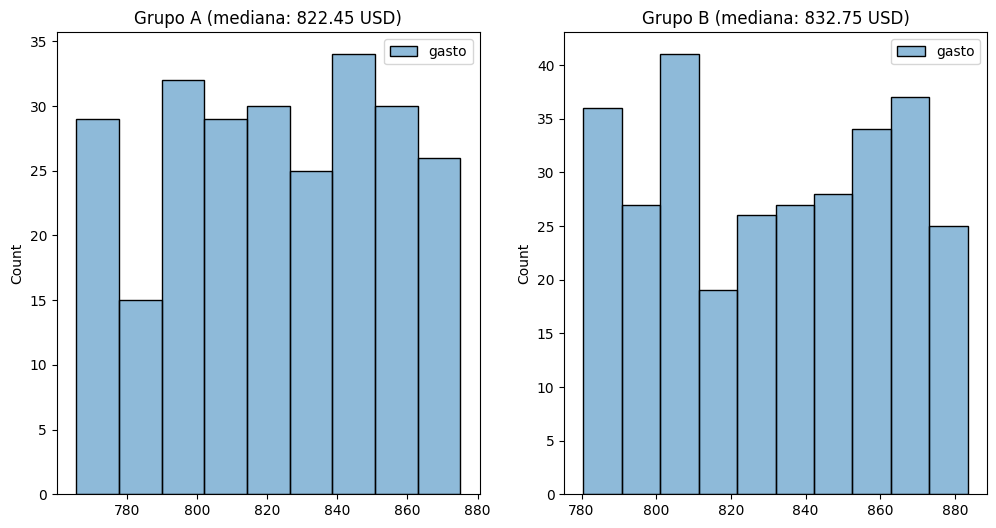

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parámetros de cada dataset
nA = len(dfA)
theta_A = dfA.median().values[0]
nB = len(dfB)
theta_B = dfB.median().values[0]

# Graficar histogramas
fig, axs = plt.subplots(1,2,figsize=(12,6))

sns.histplot(dfA, ax=axs[0])
axs[0].set_title(f"Grupo A (mediana: {theta_A:.2f} USD)")

sns.histplot(dfB, ax=axs[1])
axs[1].set_title(f"Grupo B (mediana: {theta_B:.2f} USD)");

Numéricamente la mediana del grupo A es menor que la del grupo B, aunque debemos verificar esto de forma estadística usando la prueba U de Mann-Whitney.

También vemos que los datos no tienen distribución normal. Verifiquemos esto usando la prueba de Shapiro:

In [5]:
from scipy.stats import shapiro

W1, p_shapiro1 = shapiro(dfA['gasto'])
W2, p_shapiro2 = shapiro(dfB['gasto'])
print(f"p_1: {p_shapiro1}")
print(f"p_2: {p_shapiro2}")

p_1: 2.4437398753455127e-06
p_2: 3.621853367982512e-09


Y en ambos casos vemos que p<0.05 lo cual nos indica que muy probablemente las muestras NO tienen una distribución normal, lo cual justifica el uso de la prueba U de Mann-Whitney

### 1.7. Paso 7: aplicar la prueba estadística para obtener el valor p

Al igual que en la lección anterior, podemos usar Scipy o "pingouin" para aplicar esta prueba.

Usemos el módulo "mwu" de pingouin:

In [6]:
from pingouin import mwu

resultados = mwu(
    x = dfA['gasto'].values,
    y = dfB['gasto'].values,
    alternative = 'less', # Nos interesa ver si la mediana de x (A) es menor que la de y (B) (otras opciones: greater o two-sided)
)
resultados


,U-val,alternative,p-val,RBC,CLES
MWU,31264.0,less,0.00039,-0.166293,0.583147


Vemos que:

- p < 0.05: hay más evidencia estadística a favor de la hipótesis alterna (grupo A tiende a tener menores valores que el grupo B)
- RBC (el tamaño del efecto) es -0.17: el (-) confirma que A tiende a tener menores valores que B, mientras que la magnitud (0.17) indica un tamaño del efecto "pequeño"
- CLES: 0.58. Es decir P(B>A) es del 58.3%. Es como decir: hay un 58.3% de probabilidad que un usuario B gaste más que un usuario del grupo A

### 1.8. Paso 8: aceptar o rechazar $H_0$

Con la prueba anterior nos podemos inclinar a favor de $H_1$ (la media de A es menor que la de B).

Y por tanto:

> El diseño del sitio web B genera un incremento en la mediana del gasto por usuario en comparación con el sitio web A (832.8 USD vs. 822.5 USD)

### 1.9. Paso 9: evaluar el tamaño del efecto y la potencia de la prueba actualizadas

El tamaño del efecto ya lo evaluamos con Pingouin (-0.17).

Así que nos falta estimar la potencia tras la aplicación de la prueba. Para ello usaremos un método similar al que vimos en la lección anterior:

In [7]:
from pingouin import power_ttest2n # potencia para muestras independientes cuando las muestras tienen diferentes tamaños


rbc_ph = -0.166293
d_cohen = 2*rbc_ph/math.sqrt(1-rbc_ph**2)
potencia_ph = power_ttest2n(
    nx = nA, #250
    ny = nB, #300
    d = d_cohen,
    alpha=alpha, # el 0.05 definido anteriormente
    alternative='less'
)
print(f"Potencia Post-hoc: {potencia_ph:.4f}")


Potencia Post-hoc: 0.9890
